<a href="https://colab.research.google.com/github/chpham92/chpham92/blob/main/PROJECT_Essay_Writer_Reflection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install requests
!pip install pandas
!pip install python-dotenv
!pip install pypdf
!pip install langchain-community
!pip install langchain-core
!pip install langchain-openai
!pip install langchain-text-splitters
!pip install langgraph
!pip install semantic-router
!pip install pinecone
!pip install serpapi
!pip install google-search-results
!pip install tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.3/336.3 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 40.1 MB/s eta 0:00:00
  Attempting u

In [10]:
!pip install tavily-python

In [19]:
!pip install -q langgraph-checkpoint-sqlite

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.4/163.4 kB 12.4 MB/s eta 0:00:00


In [2]:
from google.colab import userdata
openai_api_key = userdata.get('OPENAI_API_KEY_RAG')

In [3]:
from google.colab import userdata
tav_api_key = userdata.get('TAVILY_API_KEY')

In [5]:
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ChatMessage
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI

model = ChatOpenAI(api_key=openai_api_key, model='gpt-5.1', temperature=0)

In [6]:
from typing import TypedDict, List, Annotated

# CReating a class for the agent state
class AgentState(TypedDict):
  task: str
  plan: str
  draft: str
  critique: str
  content: List[str]
  revision_number: int
  max_revisions: int

In [7]:
# Defining the planning prompt
PLAN_PROMPT = '''You are an expert writer tasked with writing a high level outline of an essay.
Write such an outline for the user provided topic.
Give an outline of the essay along with any relevant notes or instructions for the sections.'''

# defining the prompt that will be used by the agent that's doing research after the planning step
# given a plan, it will generate some queries and pass them to Tavily
RESEARCH_PLAN_PROMPT = '''You are a researcher charged with providing information that can be used when writing the following essay.
Generate a list of search queries that will gather any relevant information. Only generate 3 queries max.'''

# Defining the writer prompt
WRITER_PROMPT = '''You are an essay assistant tasked with writing excellent 5-paragraph essays.
Generate the best essay possible for the user's request and the initial outline.
If the user provides critique, respond with a revised version of your previous attempts.
Utilize all the information below as needed:

------

{content}'''

# Defining the reflection prompt
REFLECTION_PROMPT = '''You are a teacher grading an essay submission.
Generate critique and recommendations for the user's submission.
Provide detailed recommendations, including requests for length, depth, style, etc.'''

# Defining the research critique prompt
RESEARCH_CRITIQUE_PROMPT = ''''You are a researcher charged with providing information that can \
be used when making any requested revisions (as outlined below).
Generate a list of search queries that will gather any relevant information. Only generate 3 queries max.'''


In [8]:
from pydantic import BaseModel

class Queries(BaseModel):
  queries: List[str]

In [11]:
# Importing and instantiating a tavily client
from tavily import TavilyClient
import os

tavily = TavilyClient(api_key=tav_api_key)

## Implementing the Agents and the Nodes

In [12]:
# Creating the planning node
def plan_node(state: AgentState):
  messages = [
      SystemMessage(content=PLAN_PROMPT),
      HumanMessage(content=state['task'])
  ]
  response = model.invoke(messages)
  return {"plan": response.content}

In [13]:
# Creating the research_plan node
# It generates research queries based on a given task and retrieves relevant content using those queries
def research_plan_node(state: AgentState):
  queries = model.with_structured_output(Queries).invoke([
      SystemMessage(content=RESEARCH_PLAN_PROMPT),
      HumanMessage(content=state['task'])
  ])
  content = state.get('content', [])

  for q in queries.queries:
    response = tavily.search(query=q, max_results=2)
    for r in response['results']:
      content.append(r['content'])
  return {'content': content}

In [14]:
# Creating the generation node
def generation_node(state: AgentState):
  content = "\n\n".join(state['content'] or [])

  user_message = HumanMessage(
      content=f"{state['task']}\n\nHere is my plan:\n\n{state['plan']}")

  messages = [
      SystemMessage(
          content=WRITER_PROMPT.format(content=content)
      ),
      user_message
  ]
  response = model.invoke(messages)

  return {
      "draft": response.content,
      "revision_number": state.get("revision_number", 1) + 1
  }

In [15]:
# Creating the reflection node
def reflection_node(state: AgentState):
  messages = [
      SystemMessage(content=REFLECTION_PROMPT),
      HumanMessage(content=state['draft'])
  ]
  response = model.invoke(messages)
  return {"critique": response.content}

In [25]:
def research_critique_node(state: AgentState):
  queries = model.with_structured_output(Queries).invoke([
      SystemMessage(content=RESEARCH_CRITIQUE_PROMPT),
      HumanMessage(content=state['critique'])
  ])
  content = state['content'] or []
  for q in queries.queries:
    response = tavily.search(query=q, max_results=2)
    for r in response['results']:
      content.append(r['content'])
  return {'content': content}

## Defining the Conditional Edge

In [28]:
# Defining the conditional edge
def should_continue(state):
  if state['revision_number'] > state['max_revisions']:
    return END
  return 'reflect'

## Defining the Graph

In [29]:
builder = StateGraph(AgentState)

# Adding nodes to the graph
builder.add_node('planner', plan_node)
builder.add_node('generate', generation_node)
builder.add_node('reflect', reflection_node)
builder.add_node('research_plan', research_plan_node)
builder.add_node('research_critique', research_critique_node)

# Setting the entry point of the state graph
builder.set_entry_point('planner')

# Adding the conditional edge
builder.add_conditional_edges(
    'generate',
    should_continue,
    {END: END, 'reflect': 'reflect'}
)

# Adding regular edges
builder.add_edge('planner', 'research_plan')
builder.add_edge('research_plan', 'generate')
builder.add_edge('reflect', 'research_critique')
builder.add_edge('research_critique', 'generate')

In [30]:
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.checkpoint.memory import MemorySaver

memory = SqliteSaver.from_conn_string('memory')
graph = builder.compile(checkpointer=MemorySaver())

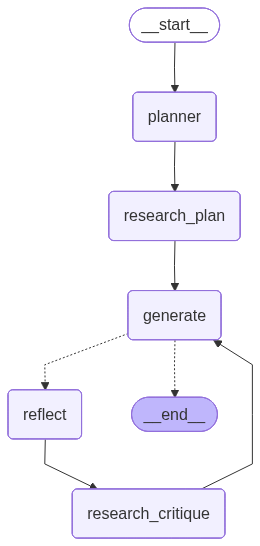

In [31]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

## Running the Agentic App

In [32]:
thread = {'configurable': {'thread_id': '1'}}
task = "Nvidia Blackwell AI chip"

prompt = {
    'task': task,
    'max_revisions': 2,
    'revision_number': 1
}

events = graph.stream(prompt, thread)
for e in events:
  print(e)
  print('-' * 100)

{'planner': {'plan': '**Essay Topic:** Nvidia Blackwell AI Chip\n\n---\n\n## I. Introduction  \n- **Purpose of the essay**  \n  - Introduce the Nvidia Blackwell AI chip as Nvidia’s next-generation GPU architecture for AI and accelerated computing.  \n- **Brief context**  \n  - Position Blackwell in the lineage of Nvidia architectures (e.g., Pascal → Volta → Turing → Ampere → Hopper → Blackwell).  \n  - Note why Blackwell is significant: scaling AI, especially large language models, real-time inference, and data center efficiency.  \n- **Thesis statement (example)**  \n  - Blackwell represents a major step in performance, efficiency, and system design, reshaping how large-scale AI workloads are trained and deployed.\n\n---\n\n## II. Background: Nvidia and AI Acceleration  \n- **Nvidia’s role in AI over the past decade**  \n  - GPUs as the backbone of deep learning since around 2012.  \n  - Transition from gaming graphics to data center, cloud, and enterprise AI.  \n- **Predecessor archi

In [33]:
print(e['generate']['draft'])

Nvidia’s Blackwell family of AI chips marks the latest stage in a decade‑long transformation of the company from a gaming graphics vendor into the de facto infrastructure layer of modern AI. Building on a lineage that runs from Pascal and Volta through Turing, Ampere, and Hopper, Blackwell is explicitly designed for a world dominated by large language models (LLMs), generative media, and trillion‑parameter simulation workloads. Where earlier generations pushed raw floating‑point throughput, Blackwell focuses on end‑to‑end system performance, energy efficiency, and total cost of ownership at data‑center scale. In doing so, it does more than incrementally accelerate AI; it reshapes how frontier‑scale models are trained, deployed, and economically justified.

Over the past decade, Nvidia’s GPUs have become the workhorses of deep learning. What began around 2012 with researchers repurposing gaming GPUs for image recognition has evolved into hyperscale data centers built almost entirely aro